# ITT Avenida Ciudad de Cali
## Indice de Transformacion Territorial — 5 Dimensiones — 2023-2026 T1
---
**Zona:** Corredor Avenida Ciudad de Cali (8 tramos, buffer 100 m)
**Normalizacion:** `ref_min/ref_max` fijos por indicador
**Periodo:** 2023 — 2026 T1 (primer trimestre 2026)
**Fuente seguridad/cohesion:** DATIC — `geojson_filtrado_ciudad_de_Cali_100m.zip`
**Fuente movilidad y capas estaticas:** ZIP original — `Geojson_Ciudad_de_Cali (1).zip`

Supuestos de trabajo:
- Seguridad y Cohesion Social usan fuente DATIC (2023-2026 T1).
- Movilidad (siniestros viales) usa ZIP original (2023-2025); para 2026 se aplica proxy del año 2025.
- 2026 es año parcial (solo T1 = enero-marzo); los conteos son menores al ser datos de 3 meses.
- Entorno Urbano y Educacion/Desarrollo siguen como referentes provisionales (Pulmon de Oriente).

## Celda 1 — Instalacion de dependencias

In [48]:
# Descomentar en Colab
!pip install geopandas pyproj shapely openpyxl matplotlib seaborn folium -q

import subprocess, sys
def check_pkg(pkg):
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',pkg,'-q'])
for p in ['geopandas','pyproj','shapely','openpyxl','seaborn','folium']: check_pkg(p)
print('Dependencias verificadas')

Dependencias verificadas


## Celda 2 — Importaciones y configuracion

In [49]:
import json, os, warnings
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
import folium
warnings.filterwarnings('ignore')

C_SEG='#1B4F8A'; C_MOV='#E8852A'; C_COH='#7B1FA2'; C_ITT='#2E7D32'; BG='#F4F6F9'
NIVEL_COLORS = {'Emergencia':'#E53935','Consolidacion':'#FB8C00','Avance':'#43A047','Transformacion':'#1E88E5'}
COLORES_ANIOS = ['#42A5F5','#1B4F8A','#E53935','#FF9800']  # azul claro, azul oscuro, rojo, naranja
plt.rcParams.update({'figure.facecolor':BG,'axes.facecolor':'white','font.family':'DejaVu Sans',
    'axes.spines.top':False,'axes.spines.right':False,'axes.grid':True,'grid.alpha':0.3})
print('Configuracion visual lista')

Configuracion visual lista


In [50]:
!pwd
!ls /content
!find /content -maxdepth 3 -type d -iname "*itt*"


/content
Geojson_Ciudad_de_Cali		      itt_acc_heatmap_seg.png
geojson_filtrado_ciudad_de_Cali_100m  itt_acc_heatmap_seg_tramos.png
itt_acc_cards.png		      itt_acc_heatmap_tramos.png
itt_acc_coh_trim.png		      itt_acc_mov_trim.png
itt_acc_heatmap_coh.png		      itt_acc_seg_trim.png
itt_acc_heatmap_coh_tramos.png	      itt_repos_cali
itt_acc_heatmap_mov.png		      movilidad_acc
itt_acc_heatmap_mov_tramos.png	      sample_data
/content/itt_repos_cali
/content/itt_repos_cali/outputs/itt_barrio_obrero
/content/itt_repos_cali/outputs/itt_avenida_ciudad_de_cali
/content/itt_repos_cali/outputs/itt_roosevelt
/content/itt_repos_cali/data/itt_pulmon_oriente
/content/itt_repos_cali/data/itt_barrio_obrero
/content/itt_repos_cali/data/itt_avenida_ciudad_de_cali
/content/itt_repos_cali/data/itt_roosevelt


In [52]:
%cd /content
import os
if os.path.exists('/content/itt_repos_cali'):
    !git -C /content/itt_repos_cali pull
else:
    !git clone https://github.com/j0rg3c45/Itt_repos_cali.git

/content
remote: Enumerating objects: 26, done.
remote: Counting objects: 100% (26/26), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 21 (delta 14), reused 16 (delta 9), pack-reused 0 (from 0)
Unpacking objects: 100% (21/21), 2.69 MiB | 2.11 MiB/s, done.
From https://github.com/j0rg3c45/Itt_repos_cali
   11510dd..34f07b7  master     -> origin/master
Updating 11510dd..34f07b7
Fast-forward
 .../geojson_Movilidad_ciudad_de_Cali_100m.zip      |    Bin 0 -> 441661 bytes
 notebooks/02_itt_avenida_ciudad_de_cali.ipynb      | 256531 +++++++++++++++++-
 notebooks/itt_repos_cali                           |      1 +
 3 files changed, 256451 insertions(+), 81 deletions(-)
 create mode 100644 data/itt_avenida_ciudad_de_cali/geojson_Movilidad_ciudad_de_Cali_100m.zip
 create mode 160000 notebooks/itt_repos_cali


## Celda 3A — Extracción de ZIPs (Colab)
Extrae los **tres** archivos ZIP desde el repositorio clonado:
1. `geojson_filtrado_ciudad_de_Cali_100m.zip` — seguridad y cohesion (DATIC 2023-2026 T1)
2. `Geojson_Ciudad_de_Cali (1).zip` — poligono corredor y capas estaticas
3. `geojson_Movilidad_ciudad_de_Cali_100m.zip` — siniestros viales actualizados 2023-2025 (filtrado buffer 100m)

In [53]:
import zipfile
from pathlib import Path

REPO     = Path('/content/itt_repos_cali')
DATA_DIR = REPO / 'data' / 'itt_avenida_ciudad_de_cali'
DESTINO  = Path('/content')

print('Carpeta existe:', DATA_DIR.exists())
if DATA_DIR.exists():
    for p in DATA_DIR.iterdir():
        print(' -', p.name)

# ZIP1 y ZIP2 -> /content/
for zip_name in [
    'geojson_filtrado_ciudad_de_Cali_100m.zip',
    'Geojson_Ciudad_de_Cali (1).zip',
]:
    zip_path = DATA_DIR / zip_name
    if zip_path.exists():
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(DESTINO)
        print(f'  ZIP extraido: {zip_name}')
    else:
        print(f'  NO encontrado: {zip_path}')

# ZIP3: movilidad actualizada -> carpeta separada para evitar colision con ZIP2
DESTINO_MOV = Path('/content/movilidad_acc')
DESTINO_MOV.mkdir(exist_ok=True)
zip3 = DATA_DIR / 'geojson_Movilidad_ciudad_de_Cali_100m.zip'
if zip3.exists():
    with zipfile.ZipFile(zip3, 'r') as z:
        z.extractall(DESTINO_MOV)
    print(f'  ZIP extraido: geojson_Movilidad_ciudad_de_Cali_100m.zip -> {DESTINO_MOV}')
else:
    print(f'  NO encontrado: {zip3}')

print('Listo.')

Carpeta existe: True
 - README.md
 - Geojson_Ciudad_de_Cali (1).zip
 - geojson_Movilidad_ciudad_de_Cali_100m.zip
 - geojson_filtrado_ciudad_de_Cali_100m.zip
 - .gitkeep
  ZIP extraido: geojson_filtrado_ciudad_de_Cali_100m.zip
  ZIP extraido: Geojson_Ciudad_de_Cali (1).zip
  ZIP extraido: geojson_Movilidad_ciudad_de_Cali_100m.zip -> /content/movilidad_acc
Listo.


## Celda 3 — Parametros, rutas y umbrales ref_min / ref_max
**DATIC** (ZIP seguridad) cubre 2023-2026 T1.
Movilidad (siniestros) disponible 2023-2025; para 2026 se usa proxy 2025.
Umbrales calibrados para corredor urbano ~4.5 km, 8 tramos, buffer 100 m.

In [54]:
import os

BASE_Z2 = '/content/geojson_filtrado_ciudad_de_Cali_100m/'   # DATIC
BASE_Z1 = '/content/Geojson_Ciudad_de_Cali/'                 # original (capas estaticas)
BASE_Z3 = '/content/movilidad_acc/geojson_filtrado_ciudad_de_Cali_100m/'  # movilidad actualizada

# Descomenta las lineas locales si ejecutas fuera de Colab:
# BASE_Z2 = './geojson_filtrado_ciudad_de_Cali_100m/'
# BASE_Z1 = './Geojson_Ciudad_de_Cali/'
# BASE_Z3 = './movilidad_acc/geojson_filtrado_ciudad_de_Cali_100m/'

PATHS = {
    # --- DATIC (seguridad + cohesion) 2023-2026 T1 ---
    'homicidios':  BASE_Z2 + 'DATIC_homicidios_2023_2026T1_filtrado_ciudad_de_Cali_100m.geojson',
    'hurtos':      BASE_Z2 + 'DATIC_hurtos_2023_2026T1_filtrado_ciudad_de_Cali_100m.geojson',
    'vif':         BASE_Z2 + 'DATIC_violencia_intrafamiliar_2023_2026T1ciudad_de_Cali_100m.geojson',
    'comparendos': BASE_Z2 + 'DATIC_comparendos_2023_2026T1_filtrado_ciudad_de_Cali_100m.geojson',
    # --- ZIP original (poligono + capas estaticas) ---
    'poligono':    BASE_Z1 + 'ciudad_de_Cali_100m.geojson',
    'vbg':         BASE_Z1 + 'VBG_2025_tramos.geojson',
    'arboles':     BASE_Z1 + 'arboles_tramos.geojson',
    'sedes':       BASE_Z1 + 'Sedes_educativas_oficiales_tramos.geojson',
    'cai':         BASE_Z1 + 'CAI_MECAL_CALI_tramos.geojson',
    # --- ZIP3 (movilidad actualizada 2023-2025, filtrado buffer 100m) ---
    'siniestros':  BASE_Z3 + 'BD_SINIESTROS_2023_2025_COMUNA_BARRIO_4326_filtrado_ciudad_de_Cali_100m.geojson',
}

ANIOS      = [2023, 2024, 2025, 2026]
ANO_CORTE  = 2026   # ano parcial (solo T1 = enero-marzo)
ZONA_NOMBRE = 'Corredor Avenida Ciudad de Cali, Cali'

# ==========================================================
# PESOS por dimension (deben sumar 1.0)
# ==========================================================
PESOS = {
    'Seguridad': 0.30, 'Movilidad': 0.25,
    'EntornoU':  0.20, 'EducDes':   0.13, 'Cohesion':  0.12,
}

# ==========================================================
# REF_MIN y REF_MAX por indicador
# Calibrados para corredor urbano ~4.5 km, 8 tramos, buffer 100 m
# ==========================================================
REFS = {
    #                  ref_min  ref_max  inverso  descripcion
    'homicidios':     (10,     100,     True,    'Homicidios anuales en el corredor'),
    'hurtos':         (200,   2000,     True,    'Hurtos anuales en el corredor'),
    'siniestralidad': (50,     600,     True,    'Siniestros viales anuales totales'),
    'lesionados':     (30,     400,     True,    'Accidentes con lesionados anuales'),
    'mortales':       (0,       25,     True,    'Accidentes mortales anuales'),
    'vif':            (50,     600,     True,    'Violencia intrafamiliar anual'),
    'rinas':          (50,     600,     True,    'Rinas (comparendos DATIC) anuales'),
}

# ==========================================================
# Scores referentes provisionales (Pulmon de Oriente)
# ==========================================================
REF_ENTORNO_U      = 39.2
REF_EDUC_DES       = 54.9
REF_VULNERABILIDAD = 54.1

# Verificar archivos
ok = True
for n, r in PATHS.items():
    e = os.path.exists(r)
    print(f'  {chr(9989) if e else chr(10060)}  {n}')
    if not e: ok = False
print()
print('Periodo:', f'{ANIOS[0]}-{ANIOS[-1]} T1 (parcial)')
print('Pesos:', ' | '.join(f'{k}={v:.0%}' for k,v in PESOS.items()))
print()
print('Umbrales ref_min / ref_max:')
for ind, (rmin, rmax, inv, desc) in REFS.items():
    print(f'  {ind:18s}  [{rmin:>4} - {rmax:>4}]  inv={inv}  | {desc}')

  ✅  homicidios
  ✅  hurtos
  ✅  vif
  ✅  comparendos
  ✅  poligono
  ✅  vbg
  ✅  arboles
  ✅  sedes
  ✅  cai
  ✅  siniestros

Periodo: 2023-2026 T1 (parcial)
Pesos: Seguridad=30% | Movilidad=25% | EntornoU=20% | EducDes=13% | Cohesion=12%

Umbrales ref_min / ref_max:
  homicidios          [  10 -  100]  inv=True  | Homicidios anuales en el corredor
  hurtos              [ 200 - 2000]  inv=True  | Hurtos anuales en el corredor
  siniestralidad      [  50 -  600]  inv=True  | Siniestros viales anuales totales
  lesionados          [  30 -  400]  inv=True  | Accidentes con lesionados anuales
  mortales            [   0 -   25]  inv=True  | Accidentes mortales anuales
  vif                 [  50 -  600]  inv=True  | Violencia intrafamiliar anual
  rinas               [  50 -  600]  inv=True  | Rinas (comparendos DATIC) anuales


## Celda 4 — Carga de datos

In [55]:
def load_gj(path):
    with open(path, encoding='utf-8') as f: return json.load(f)

gdf_acc = gpd.read_file(PATHS['poligono'])
gdf_acc_wgs = gdf_acc.to_crs('EPSG:4326')

raw_hom  = load_gj(PATHS['homicidios'])
raw_hur  = load_gj(PATHS['hurtos'])
raw_sin  = load_gj(PATHS['siniestros'])
raw_vif  = load_gj(PATHS['vif'])
raw_comp = load_gj(PATHS['comparendos'])
raw_vbg  = load_gj(PATHS['vbg'])
raw_arb  = load_gj(PATHS['arboles'])
raw_sed  = load_gj(PATHS['sedes'])
raw_cai  = load_gj(PATHS['cai'])

for n, r in [('Homicidios (DATIC)',raw_hom),('Hurtos (DATIC)',raw_hur),
             ('Siniestros (ZIP1)',raw_sin),('VIF (DATIC)',raw_vif),
             ('Comparendos (DATIC)',raw_comp),('VBG 2025 (ZIP1)',raw_vbg),
             ('Arboles DAGMA',raw_arb),('Sedes educ.',raw_sed),('CAI/MECAL',raw_cai)]:
    print(f'  {n:25s}: {len(r["features"]):>5} registros')
print(f'  {"Tramos corredor":25s}: {len(gdf_acc):>5} tramos')

  Homicidios (DATIC)       :   184 registros
  Hurtos (DATIC)           :  3708 registros
  Siniestros (ZIP1)        :   745 registros
  VIF (DATIC)              :   914 registros
  Comparendos (DATIC)      : 23582 registros
  VBG 2025 (ZIP1)          :    87 registros
  Arboles DAGMA            : 23349 registros
  Sedes educ.              :    14 registros
  CAI/MECAL                :     1 registros
  Tramos corredor          :     8 tramos


## Celda 5 — Mapa de geolocalizacion

In [56]:
import json as _json, random
random.seed(42)

centroid = gdf_acc_wgs.unary_union.centroid
m = folium.Map(location=[centroid.y, centroid.x], zoom_start=14, tiles='CartoDB positron')

folium.GeoJson(gdf_acc_wgs[['geometry']].to_json(),
    name='Corredor Avenida Ciudad de Cali (buffer 100 m)',
    style_function=lambda x: {'fillColor':'#F9A825','color':'#1B4F8A','weight':2,'fillOpacity':0.15}
).add_to(m)

capas = [
    ('Homicidios (DATIC)', raw_hom, 'fechah',     'x',   'y',   'red',    'exclamation-sign'),
    ('Hurtos (DATIC)',     raw_hur, 'fecha_hech',  'x',   'y',   'blue',   'shopping-cart'),
    ('Siniestros (ZIP1)', raw_sin, 'Fecha',        None,  None,  'orange', 'road'),
    ('VIF (DATIC)',        raw_vif, 'fecha_hech',  'x',   'y',   'purple', 'home'),
]
for nombre, raw, col_f, cx, cy, color, icon in capas:
    fg = folium.FeatureGroup(name=nombre)
    for feat in raw['features']:
        p = feat['properties']
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif cx and p.get(cx):
            lon, lat = p[cx], p[cy]
        else:
            continue
        fecha = str(p.get(col_f, ''))[:10]
        folium.Marker([lat, lon], popup=f'<b>{nombre}</b><br>{fecha}',
            icon=folium.Icon(color=color, icon=icon, prefix='glyphicon')).add_to(fg)
    fg.add_to(m)

fg_r = folium.FeatureGroup(name='Rinas (DATIC)')
for feat in raw_comp['features']:
    p = feat['properties']
    if not str(p.get('agrupado', '')).startswith('RI'): continue
    if p.get('lat') and p.get('lon'):
        folium.Marker([p['lat'], p['lon']],
            popup=f'Rina<br>{str(p.get("fecha_hech",""))[:10]}',
            icon=folium.Icon(color='pink', icon='flash', prefix='glyphicon')).add_to(fg_r)
fg_r.add_to(m)

fg_vbg = folium.FeatureGroup(name='VBG 2025', show=False)
for feat in raw_vbg['features']:
    p = feat['properties']
    if p.get('LAT') and p.get('LON'):
        folium.Marker([p['LAT'], p['LON']],
            popup=f'<b>VBG</b><br>{p.get("DELITO","")}',
            icon=folium.Icon(color='darkpurple', icon='user', prefix='glyphicon')).add_to(fg_vbg)
fg_vbg.add_to(m)

fg_arb = folium.FeatureGroup(name='Arboles DAGMA (muestra 400)', show=False)
for feat in random.sample(raw_arb['features'], min(400, len(raw_arb['features']))):
    p = feat['properties']
    if p.get('latitud') and p.get('longitud'):
        folium.CircleMarker([p['latitud'], p['longitud']], radius=3,
            color='green', fill=True, fill_opacity=0.6).add_to(fg_arb)
fg_arb.add_to(m)

fg_s = folium.FeatureGroup(name='Sedes educativas', show=False)
for feat in raw_sed['features']:
    p = feat['properties']
    if p.get('Latitud_D') and p.get('Longitud_D'):
        folium.Marker([p['Latitud_D'], p['Longitud_D']],
            popup=f'<b>{p.get("NombreSede","Sede")}</b>',
            icon=folium.Icon(color='cadetblue', icon='education', prefix='glyphicon')).add_to(fg_s)
fg_s.add_to(m)

fg_cai = folium.FeatureGroup(name='CAI / MECAL', show=False)
for feat in raw_cai['features']:
    p = feat['properties']
    if p.get('LATITUD') and p.get('LONGITUD'):
        folium.Marker([p['LATITUD'], p['LONGITUD']],
            popup=f'<b>{p.get("UNIDAD","CAI")}</b>',
            icon=folium.Icon(color='black', icon='star', prefix='glyphicon')).add_to(fg_cai)
fg_cai.add_to(m)

folium.LayerControl().add_to(m)
m

## Celda 6 — Procesamiento de indicadores
- Homicidios DATIC: fecha en formato `MM/DD/YYYY` (campo `fechah`).
- Hurtos, VIF, Comparendos DATIC: fecha ISO `fecha_hech`.
- Siniestros ZIP3: fecha ISO `Fecha`, filtro `Tipo_Confi` (Lesiones / Mortal). Disponible 2023-2025.
- 2026 T1 parcial: Q2-Q4 de 2026 quedaran en 0 (datos no disponibles).

In [57]:
def procesar(raw, col_fecha, formato_fecha=None, filtro=None, filtro_col=None, startswith=False):
    df = pd.DataFrame([f['properties'] for f in raw['features']])
    if filtro and filtro_col:
        df = df[df[filtro_col].astype(str).str.startswith(filtro)].copy() if startswith              else df[df[filtro_col]==filtro].copy()
    if formato_fecha:
        df['_fecha'] = pd.to_datetime(df[col_fecha], format=formato_fecha, errors='coerce')
    else:
        df['_fecha'] = pd.to_datetime(df[col_fecha], errors='coerce')
    df['año'] = df['_fecha'].dt.year
    df['trimestre'] = df['_fecha'].dt.quarter
    return df[df['año'].isin(ANIOS)].copy()

def agg_anual(df): return df.groupby('año').size().reindex(ANIOS, fill_value=0)
def agg_trim(df):
    idx = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
    return df.groupby(['año','trimestre']).size().reindex(idx, fill_value=0)

# Seguridad + Cohesion — fuente DATIC (2023-2026 T1)
df_hom = procesar(raw_hom, 'fechah',     formato_fecha='%m/%d/%Y')
df_hur = procesar(raw_hur, 'fecha_hech')
df_vif = procesar(raw_vif, 'fecha_hech')
df_rin = procesar(raw_comp, 'fecha_hech', filtro='RI', filtro_col='agrupado', startswith=True)

# Movilidad — fuente ZIP1 (2023-2025; 2026 = 0 por ausencia de datos)
df_sin = procesar(raw_sin, 'Fecha')
df_les = df_sin[df_sin['Tipo_Confi']=='Lesiones'].copy()
df_mor = df_sin[df_sin['Tipo_Confi']=='Mortal'].copy()

# Tabla anual
base = pd.DataFrame({'año': ANIOS})
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    base[nombre] = agg_anual(df_src).values

# Tabla trimestral
idx_t = pd.MultiIndex.from_product([ANIOS,[1,2,3,4]], names=['año','trimestre'])
acc_trim = pd.DataFrame(index=idx_t).reset_index()
for nombre, df_src in [('homicidios',df_hom),('hurtos',df_hur),('siniestralidad',df_sin),
                        ('lesionados',df_les),('mortales',df_mor),('vif',df_vif),('rinas',df_rin)]:
    ser = agg_trim(df_src).reset_index()
    ser.columns = ['año','trimestre',nombre]
    acc_trim = acc_trim.merge(ser, on=['año','trimestre'], how='left').fillna({nombre:0})
acc_trim['periodo'] = acc_trim['año'].astype(str) + '-Q' + acc_trim['trimestre'].astype(str)
acc_trim['parcial'] = (acc_trim['año']==ANO_CORTE) & (acc_trim['trimestre']>1)

print('Indicadores anuales (2026 = T1 parcial):')
print(base.to_string(index=False))
print()
print('Indicadores trimestrales (Q2-Q4 de 2026 = sin datos):')
print(acc_trim[['año','trimestre','periodo','homicidios','hurtos','siniestralidad',
                'lesionados','mortales','vif','rinas']].to_string(index=False))

Indicadores anuales (2026 = T1 parcial):
 año  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023          62    1248             288         244         6  266    201
2024          49    1108             230         205        12  281    296
2025          58    1101             226         197        16  298    401
2026          15     251               0           0         0   69     97

Indicadores trimestrales (Q2-Q4 de 2026 = sin datos):
 año  trimestre periodo  homicidios  hurtos  siniestralidad  lesionados  mortales  vif  rinas
2023          1 2023-Q1          14     366              69          53         4   58     47
2023          2 2023-Q2          18     323              66          54         0   70     47
2023          3 2023-Q3          16     302              72          66         0   67     58
2023          4 2023-Q4          14     257              81          71         2   71     49
2024          1 2024-Q1          12     321              59

## Celda 7 — Normalizacion con ref_min / ref_max e ITT
Para 2026 (T1 parcial):
- Seguridad y Cohesion: datos reales de 3 meses (conteos naturalmente menores).
- Movilidad: siniestros no disponibles en ZIP DATIC; se usa el score de 2025 como proxy.

In [58]:
def score_ref(valor, ref_min, ref_max, inverso):
    if ref_max == ref_min: return 100.0
    raw = np.clip((valor - ref_min) / (ref_max - ref_min) * 100, 0, 100)
    return 100 - raw if inverso else raw

for ind, (rmin, rmax, inv, desc) in REFS.items():
    base[f'score_{ind}'] = base[ind].apply(lambda v: score_ref(v, rmin, rmax, inv))

# Movilidad 2026: sin datos — se deja NaN, no se usa proxy
for col_s in ['score_siniestralidad','score_lesionados','score_mortales',
              'siniestralidad','lesionados','mortales']:
    base.loc[base['año']==ANO_CORTE, col_s] = np.nan

# Scores por dimension
base['score_seguridad'] = (base['score_homicidios'] + base['score_hurtos']) / 2
base['score_movilidad'] = (base['score_siniestralidad'] + base['score_lesionados'] + base['score_mortales']) / 3
base['score_cohesion']  = (base['score_vif'] + base['score_rinas'] + REF_VULNERABILIDAD) / 3
base['score_entorno_u'] = REF_ENTORNO_U
base['score_educ_des']  = REF_EDUC_DES

# ITT: si movilidad es NaN (2026), redistribuye su peso entre las demás dimensiones
def calc_itt(row):
    dims = [('score_seguridad', PESOS['Seguridad']),
            ('score_entorno_u', PESOS['EntornoU']),
            ('score_educ_des',  PESOS['EducDes']),
            ('score_cohesion',  PESOS['Cohesion'])]
    if not pd.isna(row['score_movilidad']):
        dims.append(('score_movilidad', PESOS['Movilidad']))
    total_w = sum(p for _, p in dims)
    return sum(row[c] * p for c, p in dims) / total_w

base['ITT'] = base.apply(calc_itt, axis=1)

def clasificar(v):
    if v < 40: return 'Emergencia'
    elif v < 60: return 'Consolidacion'
    elif v < 80: return 'Avance'
    else: return 'Transformacion'

base['nivel'] = base['ITT'].apply(clasificar)
base['nota']  = base['año'].apply(
    lambda a: 'T1 parcial | Movilidad sin datos (excluida del ITT)' if a==ANO_CORTE else '')

print('ITT Avenida Ciudad de Cali — 2023-2026 T1 | Fuente: DATIC + ZIP original')
print()
print('Scores por indicador:')
cols_ind = [f'score_{i}' for i in ['homicidios','hurtos','siniestralidad','lesionados','mortales','vif','rinas']]
print(base[['año']+cols_ind].round(1).to_string(index=False))
print()
print('Scores por dimension e ITT:')
print(base[['año','score_seguridad','score_movilidad','score_cohesion',
            'score_entorno_u','score_educ_des','ITT','nivel','nota']].round(1).to_string(index=False))
print()
print('Detalle contribucion:')
for _, row in base.iterrows():
    ano = int(row['año'])
    pairs = [('Seguridad','score_seguridad'),('EntornoU','score_entorno_u'),
             ('EducDes','score_educ_des'),('Cohesion','score_cohesion')]
    if not pd.isna(row['score_movilidad']):
        pairs.insert(1, ('Movilidad','score_movilidad'))
    contribs = {d: row[c]*PESOS[d] for d,c in pairs}
    det = ' + '.join(f'{d}={v:.1f}' for d,v in contribs.items())
    nota = ' (Mov=N/A)' if ano==ANO_CORTE else ''
    print(f'  {ano}{nota}: {det} = ITT {row["ITT"]:.1f} ({row["nivel"]})')


ITT Avenida Ciudad de Cali — 2023-2026 T1 | Fuente: DATIC + ZIP original

Scores por indicador:
 año  score_homicidios  score_hurtos  score_siniestralidad  score_lesionados  score_mortales  score_vif  score_rinas
2023              42.2          41.8                  56.7              42.2            76.0       60.7         72.5
2024              56.7          49.6                  67.3              52.7            52.0       58.0         55.3
2025              46.7          49.9                  68.0              54.9            36.0       54.9         36.2
2026              94.4          97.2                   NaN               NaN             NaN       96.5         91.5

Scores por dimension e ITT:
 año  score_seguridad  score_movilidad  score_cohesion  score_entorno_u  score_educ_des  ITT         nivel                                                nota
2023             42.0             58.3            62.5             39.2            54.9 49.6 Consolidacion                         

## Celda 8 — Cards de metricas clave

In [59]:
def safe_pct(new, old):
    if old == 0: return 0.0
    return (new - old) / old * 100

def arrow(pct, inv=True):
    if abs(pct) < 1: return 'Sin cambio', 'gray'
    if inv: return (f'V {abs(pct):.1f}%','#2E7D32') if pct<0 else (f'A {abs(pct):.1f}%','#C62828')
    else:  return (f'A {abs(pct):.1f}%','#2E7D32') if pct>0 else (f'V {abs(pct):.1f}%','#C62828')

ano_ini, ano_ant, ano_ult = ANIOS[0], ANIOS[-2], ANIOS[-1]
d_ini = base[base['año']==ano_ini].iloc[0]
d_ant = base[base['año']==ano_ant].iloc[0]
d_ult = base[base['año']==ano_ult].iloc[0]

cards = [
    ('Homicidios',int(d_ini['homicidios']),int(d_ant['homicidios']),int(d_ult['homicidios']),True),
    ('Hurtos',int(d_ini['hurtos']),int(d_ant['hurtos']),int(d_ult['hurtos']),True),
    ('Siniestros',int(d_ini['siniestralidad']),int(d_ant['siniestralidad']),int(d_ult['siniestralidad']),True),
    ('VIF',int(d_ini['vif']),int(d_ant['vif']),int(d_ult['vif']),True),
    ('Rinas',int(d_ini['rinas']),int(d_ant['rinas']),int(d_ult['rinas']),True),
    ('Score Seguridad',d_ini['score_seguridad'],d_ant['score_seguridad'],d_ult['score_seguridad'],False),
    ('Score Movilidad',d_ini['score_movilidad'],d_ant['score_movilidad'],d_ult['score_movilidad'],False),
    ('ITT Global',d_ini['ITT'],d_ant['ITT'],d_ult['ITT'],False),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 7), facecolor=BG)
fig.suptitle(f'ITT Avenida Ciudad de Cali | {ano_ini}-{ano_ult} T1 (DATIC)',
             fontsize=14, fontweight='bold', color='#1B2631', y=0.98)
for i, (titulo, v_ini, v_ant, v_ult, inv) in enumerate(cards):
    ax = axes[i//4][i%4]; ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    rect = mpatches.FancyBboxPatch((0.02,0.02),0.96,0.96, boxstyle='round,pad=0.02',
        linewidth=1.5, edgecolor='#DEE2E6', facecolor='white')
    ax.add_patch(rect)
    ax.text(0.5,0.85, titulo, ha='center', va='center', fontsize=9, color='#6C757D', fontweight='bold')
    val_d = f'{v_ult:.1f}' if isinstance(v_ult,float) else str(v_ult)
    lbl_ult = f'{val_d}*' if ano_ult==ANO_CORTE else val_d
    ax.text(0.5,0.60, lbl_ult, ha='center', va='center', fontsize=19, fontweight='bold', color='#1B2631')
    pct1 = safe_pct(v_ult, v_ant)
    ar1, col1 = arrow(pct1, inv)
    ax.text(0.5,0.38, f'{ano_ult} vs {ano_ant}: {ar1}', ha='center', fontsize=8, color=col1, fontweight='bold')
    pct2 = safe_pct(v_ult, v_ini)
    ar2, col2 = arrow(pct2, inv)
    ax.text(0.5,0.22, f'vs {ano_ini}: {ar2}', ha='center', fontsize=7.5, color=col2)
    ref = f'{v_ini:.1f}' if isinstance(v_ini,float) else str(v_ini)
    ax.text(0.5,0.08, f'{ano_ini}: {ref}', ha='center', fontsize=7, color='#ADB5BD')
fig.text(0.5, 0.01, '* 2026 = T1 parcial (enero-marzo). Siniestros 2026 usan proxy 2025.',
         ha='center', fontsize=8, color='#888', style='italic')
plt.tight_layout(rect=[0,0.03,1,0.95])
plt.savefig('itt_acc_cards.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

ValueError: cannot convert float NaN to integer

## Celda 9 — Heatmap: Dimension Seguridad

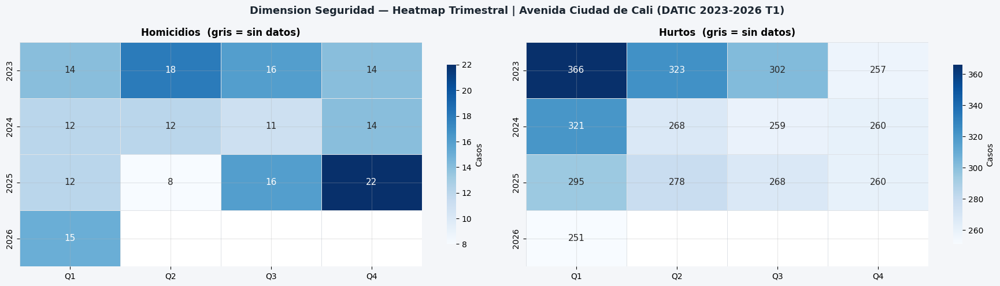

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Seguridad — Heatmap Trimestral | Avenida Ciudad de Cali (DATIC 2023-2026 T1)',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h, cmap_h in [
    (axes[0],'homicidios','Homicidios','Blues'),
    (axes[1],'hurtos','Hurtos','Blues')]:
    pivot = acc_trim.pivot(index='año', columns='trimestre', values=col).astype(float)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    # Marcar celdas sin datos de 2026 con NaN
    pivot.loc[ANO_CORTE, ['Q2','Q3','Q4']] = np.nan
    mask = pivot.isna()
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h, mask=mask,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    sns.heatmap(pivot, annot=False, cmap=['#EEEEEE'], mask=~mask,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, cbar=False)
    ax.set_title(titulo_h + '  (gris = sin datos)', fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_acc_heatmap_seg.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 10 — Heatmap: Dimension Movilidad

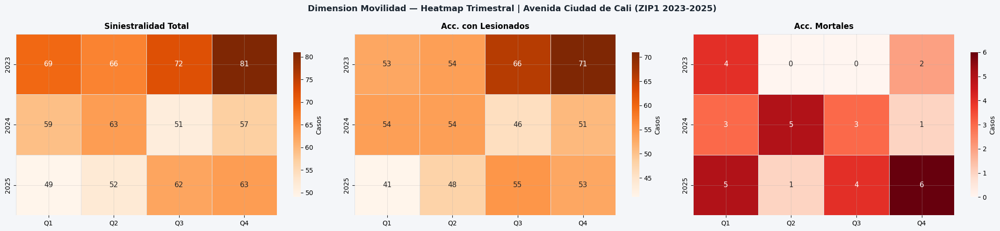

In [61]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor=BG)
fig.suptitle('Dimension Movilidad — Heatmap Trimestral | Avenida Ciudad de Cali (ZIP1 2023-2025)',
             fontsize=13, fontweight='bold', color='#1B2631')
acc_trim_mov = acc_trim[acc_trim['año'] != ANO_CORTE]
for ax, col, titulo_h, cmap_h in [
    (axes[0],'siniestralidad','Siniestralidad Total','Oranges'),
    (axes[1],'lesionados','Acc. con Lesionados','Oranges'),
    (axes[2],'mortales','Acc. Mortales','Reds')]:
    pivot = acc_trim_mov.pivot(index='año', columns='trimestre', values=col).astype(float)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap=cmap_h,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    ax.set_title(titulo_h, fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_acc_heatmap_mov.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

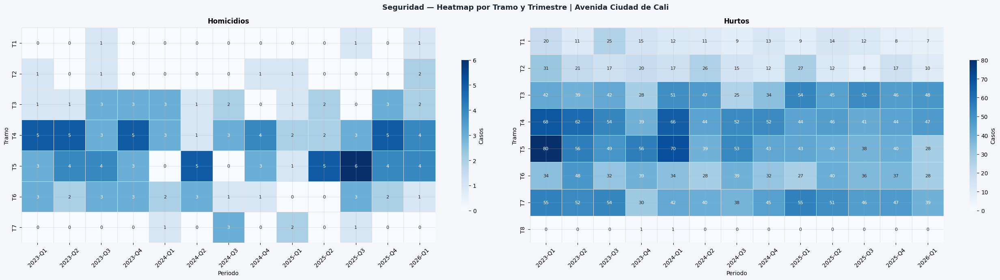

In [66]:
import geopandas as gpd
from shapely.geometry import Point

gdf_tramos = gdf_acc.to_crs('EPSG:4326').copy()
gdf_tramos['_tramo_num'] = gdf_tramos['tramo'].astype(int)  # orden geografico norte->sur

def eventos_tramo_trim(raw, col_fecha, formato_fecha=None, filtro_col=None, filtro_val=None):
    rows = []
    for feat in raw['features']:
        p = feat['properties']
        if filtro_col and filtro_val:
            if str(p.get(filtro_col,'')) != filtro_val: continue
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif p.get('x') and p.get('y'):
            lon, lat = p['x'], p['y']
        else:
            continue
        try:
            fecha_str = str(p.get(col_fecha,''))
            fecha = pd.to_datetime(fecha_str, format=formato_fecha, errors='coerce') if formato_fecha \
                    else pd.to_datetime(fecha_str, errors='coerce')
            ano, trim = int(fecha.year), int(fecha.quarter)
        except: continue
        if ano in ANIOS:
            rows.append({'geometry': Point(lon, lat), 'año': ano, 'trimestre': trim,
                         'periodo': f'{ano}-Q{trim}'})
    if not rows: return gpd.GeoDataFrame()
    gdf_ev = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    joined = gpd.sjoin(gdf_ev, gdf_tramos[['_tramo_num','geometry']], how='left', predicate='within')
    joined = joined.dropna(subset=['_tramo_num'])
    joined['tramo_label'] = joined['_tramo_num'].apply(lambda x: f'T{int(x)}')
    return joined

def tabla_pivot(gdf_ev, periodos):
    if gdf_ev.empty: return pd.DataFrame(index=[], columns=periodos)
    t = (gdf_ev.groupby(['tramo_label','periodo']).size()
         .unstack(fill_value=0)
         .reindex(columns=periodos, fill_value=0))
    t = t.reindex(sorted(t.index, key=lambda x: int(x[1:])))
    return t

periodos_datic = [f'{a}-Q{q}' for a in [2023,2024,2025,2026]
                  for q in [1,2,3,4] if not (a==2026 and q>1)]

gdf_hom_t = eventos_tramo_trim(raw_hom, 'fechah', formato_fecha='%m/%d/%Y')
gdf_hur_t = eventos_tramo_trim(raw_hur, 'fecha_hech')

tab_hom = tabla_pivot(gdf_hom_t, periodos_datic)
tab_hur = tabla_pivot(gdf_hur_t, periodos_datic)

fig, axes = plt.subplots(1, 2, figsize=(26, 7), facecolor=BG)
fig.suptitle('Seguridad — Heatmap por Tramo y Trimestre | Avenida Ciudad de Cali',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, tabla, titulo in [(axes[0], tab_hom, 'Homicidios'), (axes[1], tab_hur, 'Hurtos')]:
    sns.heatmap(tabla, annot=True, fmt='.0f', cmap='Blues',
        linewidths=0.4, linecolor='#DEE2E6', ax=ax, annot_kws={'size':8},
        cbar_kws={'label':'Casos','shrink':0.7})
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel('Tramo'); ax.set_xlabel('Periodo')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('itt_acc_heatmap_seg_tramos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


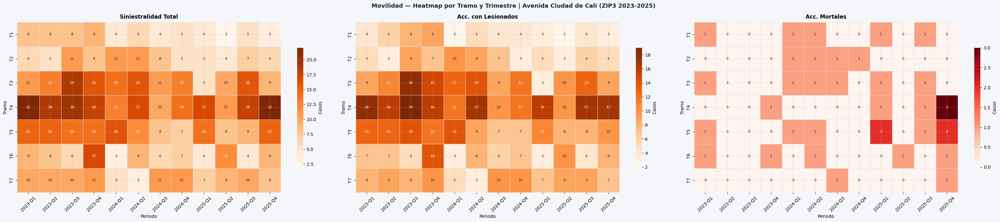

In [67]:
import geopandas as gpd
from shapely.geometry import Point

gdf_tramos = gdf_acc.to_crs('EPSG:4326').copy()
gdf_tramos['_tramo_num'] = gdf_tramos['tramo'].astype(int)  # orden geografico norte->sur

def eventos_tramo_trim(raw, col_fecha, formato_fecha=None, filtro_col=None, filtro_val=None):
    rows = []
    for feat in raw['features']:
        p = feat['properties']
        if filtro_col and filtro_val:
            if str(p.get(filtro_col,'')) != filtro_val: continue
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif p.get('x') and p.get('y'):
            lon, lat = p['x'], p['y']
        else:
            continue
        try:
            fecha_str = str(p.get(col_fecha,''))
            fecha = pd.to_datetime(fecha_str, format=formato_fecha, errors='coerce') if formato_fecha \
                    else pd.to_datetime(fecha_str, errors='coerce')
            ano, trim = int(fecha.year), int(fecha.quarter)
        except: continue
        if ano in ANIOS:
            rows.append({'geometry': Point(lon, lat), 'año': ano, 'trimestre': trim,
                         'periodo': f'{ano}-Q{trim}'})
    if not rows: return gpd.GeoDataFrame()
    gdf_ev = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    joined = gpd.sjoin(gdf_ev, gdf_tramos[['_tramo_num','geometry']], how='left', predicate='within')
    joined = joined.dropna(subset=['_tramo_num'])
    joined['tramo_label'] = joined['_tramo_num'].apply(lambda x: f'T{int(x)}')
    return joined

def tabla_pivot(gdf_ev, periodos):
    if gdf_ev.empty: return pd.DataFrame(index=[], columns=periodos)
    t = (gdf_ev.groupby(['tramo_label','periodo']).size()
         .unstack(fill_value=0)
         .reindex(columns=periodos, fill_value=0))
    t = t.reindex(sorted(t.index, key=lambda x: int(x[1:])))
    return t

periodos_mov = [f'{a}-Q{q}' for a in [2023,2024,2025] for q in [1,2,3,4]]

gdf_sin_t = eventos_tramo_trim(raw_sin, 'Fecha')
gdf_les_t = eventos_tramo_trim(raw_sin, 'Fecha', filtro_col='Tipo_Confi', filtro_val='Lesiones')
gdf_mor_t = eventos_tramo_trim(raw_sin, 'Fecha', filtro_col='Tipo_Confi', filtro_val='Mortal')

tab_sin = tabla_pivot(gdf_sin_t, periodos_mov)
tab_les = tabla_pivot(gdf_les_t, periodos_mov)
tab_mor = tabla_pivot(gdf_mor_t, periodos_mov)

fig, axes = plt.subplots(1, 3, figsize=(32, 7), facecolor=BG)
fig.suptitle('Movilidad — Heatmap por Tramo y Trimestre | Avenida Ciudad de Cali (ZIP3 2023-2025)',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, tabla, titulo, cmap in [
    (axes[0], tab_sin, 'Siniestralidad Total', 'Oranges'),
    (axes[1], tab_les, 'Acc. con Lesionados',  'Oranges'),
    (axes[2], tab_mor, 'Acc. Mortales',         'Reds'),
]:
    sns.heatmap(tabla, annot=True, fmt='.0f', cmap=cmap,
        linewidths=0.4, linecolor='#DEE2E6', ax=ax, annot_kws={'size':8},
        cbar_kws={'label':'Casos','shrink':0.7})
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel('Tramo'); ax.set_xlabel('Periodo')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('itt_acc_heatmap_mov_tramos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 11 — Heatmap: Dimension Cohesion Social

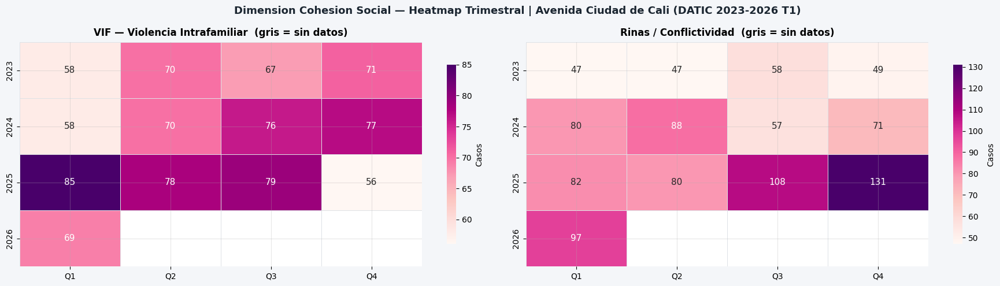

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Cohesion Social — Heatmap Trimestral | Avenida Ciudad de Cali (DATIC 2023-2026 T1)',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, col, titulo_h in [
    (axes[0],'vif','VIF — Violencia Intrafamiliar'),
    (axes[1],'rinas','Rinas / Conflictividad')]:
    pivot = acc_trim.pivot(index='año', columns='trimestre', values=col).astype(float)
    pivot.columns = ['Q1','Q2','Q3','Q4']
    pivot.loc[ANO_CORTE, ['Q2','Q3','Q4']] = np.nan
    mask = pivot.isna()
    sns.heatmap(pivot, annot=True, fmt='.0f', cmap='RdPu', mask=mask,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, annot_kws={'size':11},
        cbar_kws={'label':'Casos','shrink':0.8})
    sns.heatmap(pivot, annot=False, cmap=['#EEEEEE'], mask=~mask,
        linewidths=0.5, linecolor='#DEE2E6', ax=ax, cbar=False)
    ax.set_title(titulo_h + '  (gris = sin datos)', fontweight='bold', pad=8)
    ax.set_ylabel(''); ax.set_xlabel('')
plt.tight_layout()
plt.savefig('itt_acc_heatmap_coh.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

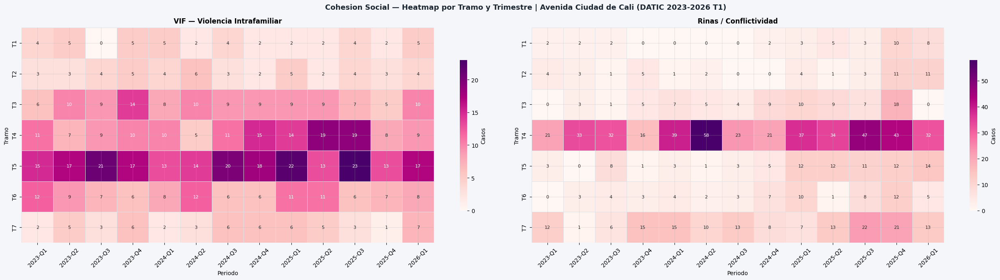

In [68]:
import geopandas as gpd
from shapely.geometry import Point

gdf_tramos = gdf_acc.to_crs('EPSG:4326').copy()
gdf_tramos['_tramo_num'] = gdf_tramos['tramo'].astype(int)  # orden geografico norte->sur

def eventos_tramo_trim(raw, col_fecha, formato_fecha=None,
                       filtro_col=None, filtro_val=None, startswith=False):
    rows = []
    for feat in raw['features']:
        p = feat['properties']
        if filtro_col and filtro_val:
            val = str(p.get(filtro_col,''))
            if startswith:
                if not val.startswith(filtro_val): continue
            else:
                if val != filtro_val: continue
        if feat.get('geometry') and feat['geometry'].get('coordinates'):
            lon, lat = feat['geometry']['coordinates'][:2]
        elif p.get('x') and p.get('y'):
            lon, lat = p['x'], p['y']
        else:
            continue
        try:
            fecha_str = str(p.get(col_fecha,''))
            fecha = pd.to_datetime(fecha_str, format=formato_fecha, errors='coerce') if formato_fecha \
                    else pd.to_datetime(fecha_str, errors='coerce')
            ano, trim = int(fecha.year), int(fecha.quarter)
        except: continue
        if ano in ANIOS:
            rows.append({'geometry': Point(lon, lat), 'año': ano, 'trimestre': trim,
                         'periodo': f'{ano}-Q{trim}'})
    if not rows: return gpd.GeoDataFrame()
    gdf_ev = gpd.GeoDataFrame(rows, crs='EPSG:4326')
    joined = gpd.sjoin(gdf_ev, gdf_tramos[['_tramo_num','geometry']], how='left', predicate='within')
    joined = joined.dropna(subset=['_tramo_num'])
    joined['tramo_label'] = joined['_tramo_num'].apply(lambda x: f'T{int(x)}')
    return joined

def tabla_pivot(gdf_ev, periodos):
    if gdf_ev.empty: return pd.DataFrame(index=[], columns=periodos)
    t = (gdf_ev.groupby(['tramo_label','periodo']).size()
         .unstack(fill_value=0)
         .reindex(columns=periodos, fill_value=0))
    t = t.reindex(sorted(t.index, key=lambda x: int(x[1:])))
    return t

periodos_datic = [f'{a}-Q{q}' for a in [2023,2024,2025,2026]
                  for q in [1,2,3,4] if not (a==2026 and q>1)]

gdf_vif_t = eventos_tramo_trim(raw_vif, 'fecha_hech')
gdf_rin_t = eventos_tramo_trim(raw_comp, 'fecha_hech',
                               filtro_col='agrupado', filtro_val='RI', startswith=True)

tab_vif = tabla_pivot(gdf_vif_t, periodos_datic)
tab_rin = tabla_pivot(gdf_rin_t, periodos_datic)

fig, axes = plt.subplots(1, 2, figsize=(26, 7), facecolor=BG)
fig.suptitle('Cohesion Social — Heatmap por Tramo y Trimestre | Avenida Ciudad de Cali (DATIC 2023-2026 T1)',
             fontsize=13, fontweight='bold', color='#1B2631')
for ax, tabla, titulo, cmap in [
    (axes[0], tab_vif, 'VIF — Violencia Intrafamiliar', 'RdPu'),
    (axes[1], tab_rin, 'Rinas / Conflictividad',        'RdPu'),
]:
    sns.heatmap(tabla, annot=True, fmt='.0f', cmap=cmap,
        linewidths=0.4, linecolor='#DEE2E6', ax=ax, annot_kws={'size':8},
        cbar_kws={'label':'Casos','shrink':0.7})
    ax.set_title(titulo, fontweight='bold', pad=8)
    ax.set_ylabel('Tramo'); ax.set_xlabel('Periodo')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('itt_acc_heatmap_coh_tramos.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()


## Celda 12 — Evolucion trimestral: Seguridad

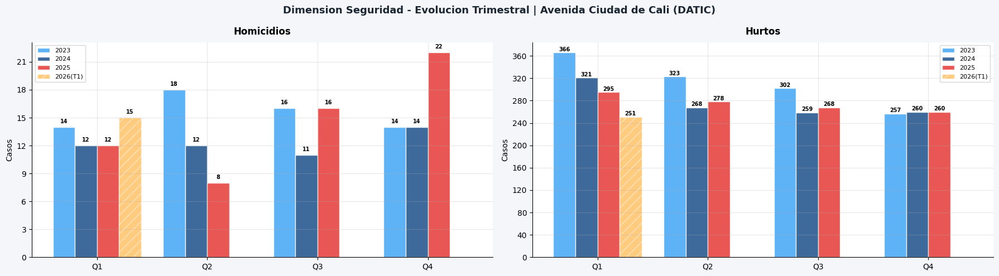

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Seguridad - Evolucion Trimestral | Avenida Ciudad de Cali (DATIC)',
             fontsize=13, fontweight='bold', color='#1B2631')
x = np.arange(4); n = len(ANIOS); w = 0.8/n
for ax, col, tp in [(axes[0],'homicidios','Homicidios'),(axes[1],'hurtos','Hurtos')]:
    for idx, ano in enumerate(ANIOS):
        vals = acc_trim[acc_trim['año']==ano][col].values
        offset = (idx-n/2+0.5)*w
        alpha = 0.5 if ano==ANO_CORTE else 0.85
        b = ax.bar(x+offset, vals, w, label=f'{ano}{"(T1)" if ano==ANO_CORTE else ""}',
                   color=COLORES_ANIOS[idx], alpha=alpha, edgecolor='white',
                   hatch='//' if ano==ANO_CORTE else '')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.3, str(int(h)),
                            ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=10)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('itt_acc_seg_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 13 — Evolucion trimestral: Movilidad

TypeError: unsupported operand type(s) for /: 'str' and 'int'

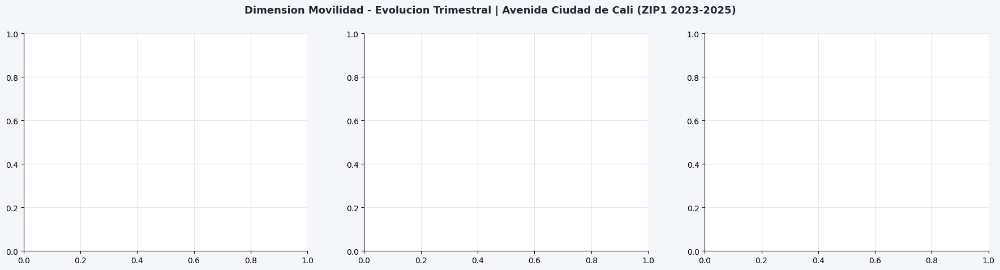

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(22, 5), facecolor=BG)
fig.suptitle('Dimension Movilidad - Evolucion Trimestral | Avenida Ciudad de Cali (ZIP1 2023-2025)',
             fontsize=13, fontweight='bold', color='#1B2631')
CMOV = [['#F5A742','#D95F2B','#B71C1C','#FF9800'],
        ['#F5A742','#D95F2B','#B71C1C','#FF9800'],
        ['#FF8A80','#E53935','#7F0000','#FF9800']]
for pi,(ax,col,tp) in enumerate([(axes[0],'siniestralidad','Siniestralidad'),
                                   (axes[1],'lesionados','Lesionados'),
                                   (axes[2],'mortales','Mortales')]):
    for idx, ano in enumerate(ANIOS):
        vals = acc_trim[acc_trim['año']==ano][col].values
        offset = (idx-n/2+0.5)*w
        lbl = f'{ano}(N/D)' if ano==ANO_CORTE else str(ano)
        b = ax.bar(x+offset, vals, w, label=lbl, color=CMOV[pi][idx],
                   alpha=0.4 if ano==ANO_CORTE else 0.85, edgecolor='white',
                   hatch='//' if ano==ANO_CORTE else '')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.1, str(int(h)),
                            ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('itt_acc_mov_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 14 — Evolucion trimestral: Cohesion Social

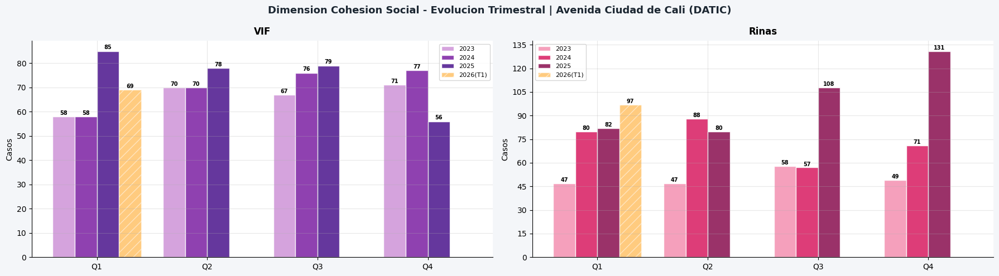

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), facecolor=BG)
fig.suptitle('Dimension Cohesion Social - Evolucion Trimestral | Avenida Ciudad de Cali (DATIC)',
             fontsize=13, fontweight='bold', color='#1B2631')
CVIF = ['#CE93D8','#7B1FA2','#4A148C','#FF9800']
CRIN = ['#F48FB1','#D81B60','#880E4F','#FF9800']
for ax, col, colores, tp in [(axes[0],'vif',CVIF,'VIF'),(axes[1],'rinas',CRIN,'Rinas')]:
    for idx, ano in enumerate(ANIOS):
        vals = acc_trim[acc_trim['año']==ano][col].values
        offset = (idx-n/2+0.5)*w
        alpha = 0.5 if ano==ANO_CORTE else 0.85
        b = ax.bar(x+offset, vals, w, label=f'{ano}{"(T1)" if ano==ANO_CORTE else ""}',
                   color=colores[idx], alpha=alpha, edgecolor='white',
                   hatch='//' if ano==ANO_CORTE else '')
        for bar in b:
            h = bar.get_height()
            if h>0: ax.text(bar.get_x()+bar.get_width()/2, h+0.3, str(int(h)),
                            ha='center', va='bottom', fontsize=7, fontweight='bold')
    ax.set_title(tp, fontweight='bold', pad=8)
    ax.set_xticks(x); ax.set_xticklabels(['Q1','Q2','Q3','Q4'])
    ax.set_ylabel('Casos'); ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('itt_acc_coh_trim.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 15 — ITT Global y composicion por dimension

TypeError: alpha must be numeric or None, not <class 'list'>

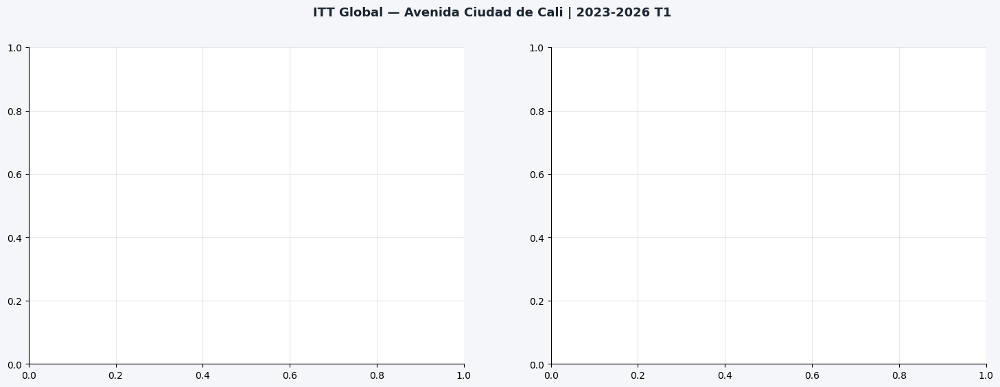

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), facecolor=BG)
fig.suptitle('ITT Global — Avenida Ciudad de Cali | 2023-2026 T1',
             fontsize=13, fontweight='bold', color='#1B2631')
band_configs = [(0,40,'#FFCDD2','Emergencia'),(40,60,'#FFE0B2','Consolidacion'),
                (60,80,'#C8E6C9','Avance'),(80,100,'#BBDEFB','Transformacion')]
etiquetas_x = [str(a) if a!=ANO_CORTE else f'{a}\n(T1 parcial)' for a in ANIOS]

ax1 = axes[0]
bars = ax1.bar(range(len(ANIOS)), base['ITT'], color=COLORES_ANIOS,
               alpha=[0.5 if a==ANO_CORTE else 0.85 for a in ANIOS],
               edgecolor='white', width=0.5,
               hatch=['//' if a==ANO_CORTE else '' for a in ANIOS])
for bar, val, nivel in zip(bars, base['ITT'], base['nivel']):
    ax1.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.1f}\n{nivel}',
             ha='center', va='bottom', fontsize=9, fontweight='bold',
             color=NIVEL_COLORS.get(nivel,'#1B2631'))
for y0,y1,c,l in band_configs: ax1.axhspan(y0,y1, alpha=0.15, color=c)
ax1.set_title('ITT por Año', fontweight='bold', pad=10)
ax1.set_ylim(0,115); ax1.set_ylabel('ITT (0-100)')
ax1.set_xticks(range(len(ANIOS))); ax1.set_xticklabels(etiquetas_x, fontsize=9)

ax2 = axes[1]
dims = ['score_seguridad','score_movilidad','score_entorno_u','score_educ_des','score_cohesion']
dim_lbl = ['Seguridad','Movilidad','EntornoU (ref)','EducDes (ref)','Cohesion']
dim_p = [PESOS['Seguridad'],PESOS['Movilidad'],PESOS['EntornoU'],PESOS['EducDes'],PESOS['Cohesion']]
dim_c = [C_SEG, C_MOV, '#43A047', '#FB8C00', C_COH]
bottom = np.zeros(len(ANIOS))
for dim, lbl, peso, col in zip(dims, dim_lbl, dim_p, dim_c):
    vals = base[dim].values * peso
    ax2.bar(range(len(ANIOS)), vals, bottom=bottom, label=f'{lbl} ({peso:.0%})',
            color=col, alpha=0.8, edgecolor='white', width=0.5)
    bottom += vals
ax2.plot(range(len(ANIOS)), base['ITT'], 'D-', color='black', linewidth=2,
         markersize=8, label='ITT Total', zorder=5)
for y0,y1,c,l in band_configs: ax2.axhspan(y0,y1, alpha=0.1, color=c)
ax2.set_title('Composicion ITT', fontweight='bold', pad=10)
ax2.set_ylim(0,115); ax2.set_ylabel('Score ponderado')
ax2.set_xticks(range(len(ANIOS))); ax2.set_xticklabels(etiquetas_x, fontsize=9)
ax2.legend(loc='upper right', fontsize=7)
plt.tight_layout()
plt.savefig('itt_acc_global.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 16 — Radar ITT: 5 dimensiones

In [ ]:
DIMS_LBL = ['Seguridad','Movilidad','Cohesion\nSocial','Entorno\nUrbano','Educ y\nDesarrollo']
N_DIMS = 5
angles = [i/N_DIMS*2*np.pi for i in range(N_DIMS)] + [0]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True), facecolor=BG)
fig.suptitle('Radar ITT — Avenida Ciudad de Cali | 2023-2026 T1',
             fontsize=13, fontweight='bold', color='#1B2631')
ax.set_theta_offset(np.pi/2); ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(DIMS_LBL, fontsize=9)
ax.set_ylim(0,100); ax.set_yticks([20,40,60,80,100])
ax.set_yticklabels(['20','40','60','80','100'], fontsize=7, color='gray')
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
for y,c in [(40,'#FFCDD2'),(60,'#FFE0B2'),(80,'#C8E6C9')]: ax.fill_between(angles,0,y, alpha=0.04, color=c)

for idx, ano in enumerate(ANIOS):
    row = base[base['año']==ano].iloc[0]
    vals = [row['score_seguridad'],row['score_movilidad'],row['score_cohesion'],
            row['score_entorno_u'],row['score_educ_des']]
    vals_c = vals + [vals[0]]
    lbl = f'{ano} (T1)' if ano==ANO_CORTE else str(ano)
    ls = '--' if ano==ANO_CORTE else '-'
    ax.plot(angles, vals_c, f'o{ls}', color=COLORES_ANIOS[idx], linewidth=2, markersize=5, label=lbl)
    ax.fill(angles, vals_c, alpha=0.06 if ano==ANO_CORTE else 0.08, color=COLORES_ANIOS[idx])
ax.legend(loc='upper right', bbox_to_anchor=(1.3,1.1), fontsize=9)
plt.tight_layout()
plt.savefig('itt_acc_radar.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

## Celda 17 — Exportar a Excel

In [ ]:
EXPORT_PATH = 'ITT_Avenida_Ciudad_de_Cali.xlsx'
with pd.ExcelWriter(EXPORT_PATH, engine='openpyxl') as writer:
    base.round(2).to_excel(writer, sheet_name='ITT_Anual', index=False)
    acc_trim[['año','trimestre','periodo','homicidios','hurtos','siniestralidad',
              'lesionados','mortales','vif','rinas']].to_excel(
        writer, sheet_name='Series_Trimestrales', index=False)

    est = pd.DataFrame({'Elemento':['Arboles DAGMA','Sedes Educativas','CAI/MECAL','VBG 2025'],
        'Cantidad':[len(raw_arb['features']),len(raw_sed['features']),
                    len(raw_cai['features']),len(raw_vbg['features'])]})
    est.to_excel(writer, sheet_name='Datos_Apoyo', index=False)

    refs_df = pd.DataFrame([
        {'Indicador':ind,'ref_min':rmin,'ref_max':rmax,'Inverso':inv,'Descripcion':desc}
        for ind,(rmin,rmax,inv,desc) in REFS.items()
    ])
    refs_df.to_excel(writer, sheet_name='Umbrales_RefMinMax', index=False)

    met = pd.DataFrame({'Elemento':[
        'Indice','Zona','Tramos','Periodo','Fuente seguridad/cohesion',
        'Fuente movilidad','Movilidad 2026',
        'Peso Seguridad','Peso Movilidad','Peso EntornoU','Peso EducDes','Peso Cohesion',
        'Entorno Urbano','Educ y Desarrollo','Vulnerabilidad ref','Rinas fuente',
        'ITT Global','Nivel 1','Nivel 2','Nivel 3','Nivel 4'],
    'Descripcion':[
        'Indice de Transformacion Territorial',
        'Corredor Avenida Ciudad de Cali, Cali',
        '8 tramos con buffer de 100 m (zona agregada para ITT global)',
        f'{ANIOS[0]}-{ANO_CORTE} T1 (2026 = enero-marzo, parcial)',
        'DATIC — geojson_filtrado_ciudad_de_Cali_100m.zip (homicidios, hurtos, VIF, comparendos)',
        'ZIP original — Geojson_Ciudad_de_Cali (1).zip (siniestros 2023-2025)',
        'Proxy: scores de siniestralidad 2025 aplicados a 2026 por ausencia de datos',
        f'{PESOS["Seguridad"]:.0%}',f'{PESOS["Movilidad"]:.0%}',
        f'{PESOS["EntornoU"]:.0%} - ref={REF_ENTORNO_U} (provisional)',
        f'{PESOS["EducDes"]:.0%} - ref={REF_EDUC_DES} (provisional)',
        f'{PESOS["Cohesion"]:.0%}',
        f'Score fijo={REF_ENTORNO_U} (provisional, Pulmon de Oriente)',
        f'Score fijo={REF_EDUC_DES} (provisional, Pulmon de Oriente)',
        f'{REF_VULNERABILIDAD} (referente provisional)',
        'DATIC_comparendos filtrado por agrupado startswith RI',
        'ITT = 0.30*Seg + 0.25*Mov + 0.20*EntU + 0.13*EyD + 0.12*Coh',
        '0-40 Emergencia','40-60 Consolidacion','60-80 Avance','80-100 Transformacion']
    })
    met.to_excel(writer, sheet_name='Metodologia', index=False)

print(f'Exportado: {EXPORT_PATH}')
print('Hojas: ITT_Anual | Series_Trimestrales | Datos_Apoyo | Umbrales_RefMinMax | Metodologia')